# Notebook 08b — LightGBM: Weather Effects on Cycling Demand

Drop-in replacement for `08_gam_model`.  
Uses **LightGBM with Poisson objective** for prediction and **SHAP** for interpretation.

| | GAM (notebook 08) | LightGBM (this notebook) |
|---|---|---|
| Distribution | Poisson | Poisson |
| Nonlinearity | Splines (hand-crafted) | Gradient boosted trees (learned) |
| Interactions | None | Automatic |
| Interpretability | Partial dependence (closed-form) | SHAP values (TreeExplainer) |
| Speed | 2–5 min | < 30 sec |

All downstream notebooks (09, 10) are **fully compatible**: same output files, same API.


## 0. Imports & Setup

In [8]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lightgbm", "shap"])


0

In [9]:
import pickle
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Disable SHAP's progress bar for cleaner output
shap.initjs()
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

COLORS = {
    "commuter" : "#2196F3",
    "mixed"    : "#FFC107",
    "leisure"  : "#F44336",
}
site_cls = pd.read_parquet(PROCESSED / "site_classification.parquet")[
    ["site ID", "commute_score", "site_type"]
]
panel = panel.drop(columns=[c for c in ["commute_score", "site_type"] if c in panel.columns])
panel = panel.merge(site_cls, on="site ID", how="left")
panel["site_type"] = panel["site_type"].fillna("unclassified")
panel = pd.read_parquet(PROCESSED / "analysis_panel.parquet")
panel_good = panel[
    (panel["low_coverage"] == False) &
    (panel["aantal"].notna()) &
    (panel["temp_avg"].notna())
].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

train = panel_good[panel_good["date"].dt.year == 2024].copy()
test  = panel_good[panel_good["date"].dt.year == 2025].copy()

print(f"Train size : {len(train):,} rows (2024)")
print(f"Test size  : {len(test):,} rows (2025)")
print(f"Columns    : {list(panel_good.columns)}")


Train size : 48,351 rows (2024)
Test size  : 48,151 rows (2025)
Columns    : ['site ID', 'date', 'aantal', 'morning_peak_count', 'evening_peak_count', 'peak_ratio', 'year', 'month', 'dayofweek', 'is_weekend', 'season', 'low_coverage', 'long', 'lat', 'naam', 'gemeente', 'wegnr', 'district', 'datum_van', 'temp_avg', 'temp_max', 'temp_min', 'precip_total', 'wind_avg', 'wind_max', 'humidity_avg', 'sunshine_min', 'rain_hours', 'precip_morning', 'wind_morning', 'precip_evening', 'wind_evening', 'is_rainy_day', 'is_cold_day', 'is_windy_day', 'is_bad_weather', 'public_holiday_name', 'is_public_holiday', 'school_holiday_name', 'is_school_holiday', 'ku_leuven_period', 'ku_is_teaching', 'ku_is_exam', 'ku_is_exam_prep', 'ku_is_recess', 'is_any_holiday', 'is_regular_day', 'day_type', 'temp_avg_lag1', 'precip_total_lag1', 'wind_avg_lag1', 'temp_avg_lag2', 'precip_total_lag2', 'wind_avg_lag2']


## 1. Feature Engineering
Identical to notebook 08 — same features, same encoding.

In [10]:
le_site = LabelEncoder()
train["site_idx"] = le_site.fit_transform(train["site ID"])
test["site_idx"]  = le_site.transform(test["site ID"])

train["dow"]       = train["dayofweek"].astype(int)
test["dow"]        = test["dayofweek"].astype(int)
train["month_int"] = train["month"].astype(int)
test["month_int"]  = test["month"].astype(int)

for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_bad_weather"]:
    train[col] = train[col].astype(int)
    test[col]  = test[col].astype(int)

WEATHER_FEATURES  = [
    "temp_avg", "precip_total", "wind_avg",
    "sunshine_min", "humidity_avg",
    "temp_avg_lag1", "precip_total_lag1",
]
CALENDAR_FEATURES = [
    "dow", "month_int",
    "is_weekend", "is_public_holiday", "is_school_holiday",
]
SITE_FEATURE = ["site_idx"]
ALL_FEATURES = WEATHER_FEATURES + CALENDAR_FEATURES + SITE_FEATURE

# LightGBM categorical feature indices (dow, month_int, binary flags, site)
CAT_FEATURES = ["dow", "month_int",
                "is_weekend", "is_public_holiday", "is_school_holiday",
                "site_idx"]

print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"Categorical : {CAT_FEATURES}")
print(f"Train shape: {train.shape}  |  Test shape: {test.shape}")


Features (13): ['temp_avg', 'precip_total', 'wind_avg', 'sunshine_min', 'humidity_avg', 'temp_avg_lag1', 'precip_total_lag1', 'dow', 'month_int', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'site_idx']
Categorical : ['dow', 'month_int', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'site_idx']
Train shape: (48351, 57)  |  Test shape: (48151, 57)


## 2. Prepare Feature Matrix

In [11]:
def make_X_y(df, features):
    cols = features + ["aantal"]
    df_clean = df[cols].dropna()
    X = df_clean[features].values.astype(np.float64)
    y = df_clean["aantal"].values.astype(np.float64)
    return X, y, df_clean.index

X_train, y_train, train_idx = make_X_y(train, ALL_FEATURES)
X_test,  y_test,  test_idx  = make_X_y(test,  ALL_FEATURES)

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"y_train — mean: {y_train.mean():.1f}, std: {y_train.std():.1f}, "
      f"min: {y_train.min():.0f}, max: {y_train.max():.0f}")

# Dispersion check: if var >> mean, Poisson is still appropriate but
# NegBin would fit better (see notebook 08c).
dispersion = y_train.var() / y_train.mean()
print(f"\nDispersion ratio (var/mean) = {dispersion:.1f}  "
      f"{'— overdispersed, consider NegBin' if dispersion > 3 else '— Poisson OK'}")


X_train : (48351, 13)  |  y_train : (48351,)
X_test  : (48151, 13)   |  y_test  : (48151,)
y_train — mean: 489.7, std: 661.9, min: 0, max: 37188

Dispersion ratio (var/mean) = 894.4  — overdispersed, consider NegBin


## 3. LightGBM Hyperparameters & Training Utilities

In [12]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
# Poisson objective: model learns log(E[y]), predict() returns E[y] directly.
LGB_PARAMS = dict(
    objective         = "poisson",
    metric            = "poisson",       # log-loss for Poisson
    poisson_max_delta_step = 0.7,        # numerical stability; default 0.7
    num_leaves        = 63,
    max_depth         = -1,
    learning_rate     = 0.05,
    n_estimators      = 2000,            # early stopping keeps what's needed
    feature_fraction  = 0.8,
    bagging_fraction  = 0.8,
    bagging_freq      = 5,
    min_child_samples = 20,
    reg_alpha         = 0.1,             # L1
    reg_lambda        = 1.0,             # L2
    verbose           = -1,
    n_jobs            = -1,
    random_state      = 42,
)

def eval_metrics(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    if label:
        print(f"  {label:<15}  MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}")
    return mae, rmse, r2

def train_lgb(X_tr, y_tr, X_val, y_val, params=LGB_PARAMS, cat_cols_idx=None):
    """Train LightGBM with early stopping on a held-out validation split."""
    dtrain = lgb.Dataset(
        X_tr, label=y_tr,
        feature_name=ALL_FEATURES,
        categorical_feature=CAT_FEATURES,
    )
    dval = lgb.Dataset(
        X_val, label=y_val,
        feature_name=ALL_FEATURES,
        categorical_feature=CAT_FEATURES,
        reference=dtrain,
    )
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100),
    ]
    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dval],
        callbacks=callbacks,
    )
    print(f"    Best iteration: {model.best_iteration}")
    return model

# Use last 2 months of 2024 (Nov–Dec) as internal validation for early stopping
val_mask = train["date"].dt.month >= 11
X_val_es = X_train[train.loc[train_idx, "date"].dt.month >= 11]
y_val_es = y_train[train.loc[train_idx, "date"].dt.month >= 11]
X_tr_es  = X_train[train.loc[train_idx, "date"].dt.month < 11]
y_tr_es  = y_train[train.loc[train_idx, "date"].dt.month < 11]

print(f"Early-stopping split — "
      f"train: {len(X_tr_es):,}  val (Nov–Dec 2024): {len(X_val_es):,}")


Early-stopping split — train: 40,388  val (Nov–Dec 2024): 7,963


## 4. Model A — Full LightGBM (all stations)

Same scope as `gam_full` in notebook 08.


In [13]:
print("Fitting full LightGBM...")
lgb_full = train_lgb(X_tr_es, y_tr_es, X_val_es, y_val_es)

y_pred_train_full = lgb_full.predict(X_train)
y_pred_test_full  = lgb_full.predict(X_test)

print("\n" + "=" * 52)
print("MODEL A — Full LightGBM Performance")
print("=" * 52)
mae_full_tr, rmse_full_tr, _ = eval_metrics(y_train, y_pred_train_full, "Train")
mae_full, rmse_full, r2_full = eval_metrics(y_test,  y_pred_test_full,  "Test")
print("=" * 52)

# Feature importance (gain)
fi = pd.Series(
    lgb_full.feature_importance(importance_type="gain"),
    index=ALL_FEATURES
).sort_values(ascending=False)
print("\nTop-10 features by gain:")
print(fi.head(10).round(0).to_string())


Fitting full LightGBM...
[100]	valid_0's poisson: -2030.46
[200]	valid_0's poisson: -2042.86
[300]	valid_0's poisson: -2046.01
[400]	valid_0's poisson: -2046.95
[500]	valid_0's poisson: -2047.44
[600]	valid_0's poisson: -2048.14
[700]	valid_0's poisson: -2048.79
[800]	valid_0's poisson: -2049.02
[900]	valid_0's poisson: -2049.21
[1000]	valid_0's poisson: -2049.37
[1100]	valid_0's poisson: -2049.46
[1200]	valid_0's poisson: -2049.56
[1300]	valid_0's poisson: -2049.76
[1400]	valid_0's poisson: -2049.85
    Best iteration: 1406

MODEL A — Full LightGBM Performance
  Train            MAE=39.8  RMSE=84.3  R²=0.984
  Test             MAE=118.1  RMSE=272.4  R²=0.852

Top-10 features by gain:
site_idx             141756576.0
sunshine_min           4802825.0
month_int              4774755.0
temp_avg               4532018.0
precip_total           3707201.0
is_weekend             3005932.0
temp_avg_lag1          2760025.0
wind_avg               2598993.0
dow                    2533360.0
precip_to

## 5. Model B — Commuter LightGBM

In [15]:
from pathlib import Path
PROCESSED = Path().resolve().parent / "data" / "processed"

_site_cls = pd.read_parquet(PROCESSED / "site_classification.parquet")[
    ["site ID", "site_type"]
]
for _df in [train, test]:
    if "site_type" not in _df.columns:
        _site_map = _site_cls.set_index("site ID")["site_type"]
        _df["site_type"] = _df["site ID"].map(_site_map).fillna("unclassified")
train_c = train[train["site_type"] == "commuter"].copy()
test_c  = test[test["site_type"]  == "commuter"].copy()

le_c = LabelEncoder()
train_c["site_idx"] = le_c.fit_transform(train_c["site ID"])
test_c["site_idx"]  = le_c.transform(test_c["site ID"])

X_train_c, y_train_c, _ = make_X_y(train_c, ALL_FEATURES)
X_test_c,  y_test_c,  _ = make_X_y(test_c,  ALL_FEATURES)

# Early-stopping split for commuter
val_mask_c   = train_c["date"].dt.month >= 11
idx_rows_c   = train_c.reset_index(drop=True)
X_tr_c_es    = X_train_c[idx_rows_c["date"].dt.month < 11]
y_tr_c_es    = y_train_c[idx_rows_c["date"].dt.month < 11]
X_val_c_es   = X_train_c[idx_rows_c["date"].dt.month >= 11]
y_val_c_es   = y_train_c[idx_rows_c["date"].dt.month >= 11]

print("Fitting commuter LightGBM...")
lgb_commuter = train_lgb(X_tr_c_es, y_tr_c_es, X_val_c_es, y_val_c_es)

y_pred_c = lgb_commuter.predict(X_test_c)
print()
mae_c, rmse_c, r2_c = eval_metrics(y_test_c, y_pred_c, "Commuter test")


Fitting commuter LightGBM...
[100]	valid_0's poisson: -2081.13
[200]	valid_0's poisson: -2091.56
[300]	valid_0's poisson: -2093.9
[400]	valid_0's poisson: -2094.72
[500]	valid_0's poisson: -2095.13
[600]	valid_0's poisson: -2095.35
[700]	valid_0's poisson: -2095.55
[800]	valid_0's poisson: -2095.63
[900]	valid_0's poisson: -2095.75
[1000]	valid_0's poisson: -2095.76
[1100]	valid_0's poisson: -2095.83
[1200]	valid_0's poisson: -2095.91
[1300]	valid_0's poisson: -2095.95
[1400]	valid_0's poisson: -2096.02
    Best iteration: 1435

  Commuter test    MAE=116.9  RMSE=254.2  R²=0.782


## 6. Model C — Leisure LightGBM

In [16]:
train_l = train[train["site_type"] == "leisure"].copy()
test_l  = test[test["site_type"]  == "leisure"].copy()

le_l = LabelEncoder()
train_l["site_idx"] = le_l.fit_transform(train_l["site ID"])
test_l["site_idx"]  = le_l.transform(test_l["site ID"])

X_train_l, y_train_l, _ = make_X_y(train_l, ALL_FEATURES)
X_test_l,  y_test_l,  _ = make_X_y(test_l,  ALL_FEATURES)

idx_rows_l = train_l.reset_index(drop=True)
X_tr_l_es  = X_train_l[idx_rows_l["date"].dt.month < 11]
y_tr_l_es  = y_train_l[idx_rows_l["date"].dt.month < 11]
X_val_l_es = X_train_l[idx_rows_l["date"].dt.month >= 11]
y_val_l_es = y_train_l[idx_rows_l["date"].dt.month >= 11]

print("Fitting leisure LightGBM...")
lgb_leisure = train_lgb(X_tr_l_es, y_tr_l_es, X_val_l_es, y_val_l_es)

y_pred_l = lgb_leisure.predict(X_test_l)
print()
mae_l, rmse_l, r2_l = eval_metrics(y_test_l, y_pred_l, "Leisure test")

print("\n" + "=" * 52)
print("MODEL COMPARISON")
print("=" * 52)
print(f"{'Model':<15} | {'Test MAE':>9} | {'Test R²':>8}")
print("-" * 40)
print(f"{'Full (all)':<15} | {mae_full:>8.1f}  | {r2_full:>7.3f}")
print(f"{'Commuter only':<15} | {mae_c:>8.1f}  | {r2_c:>7.3f}")
print(f"{'Leisure only':<15} | {mae_l:>8.1f}  | {r2_l:>7.3f}")
print("=" * 52)


Fitting leisure LightGBM...
[100]	valid_0's poisson: -1460.58
[200]	valid_0's poisson: -1471.16
[300]	valid_0's poisson: -1474.67
[400]	valid_0's poisson: -1476.05
[500]	valid_0's poisson: -1477.14
[600]	valid_0's poisson: -1478.81
[700]	valid_0's poisson: -1479.16
[800]	valid_0's poisson: -1479.73
[900]	valid_0's poisson: -1480.63
[1000]	valid_0's poisson: -1481.5
[1100]	valid_0's poisson: -1481.68
[1200]	valid_0's poisson: -1481.91
    Best iteration: 1176

  Leisure test     MAE=127.3  RMSE=300.6  R²=0.785

MODEL COMPARISON
Model           |  Test MAE |  Test R²
----------------------------------------
Full (all)      |    118.1  |   0.852
Commuter only   |    116.9  |   0.782
Leisure only    |    127.3  |   0.785


## 7. SHAP Partial Dependence Plots — fig20b

**How SHAP relates to GAM partial dependence**  
LightGBM with Poisson objective predicts `log(E[count])` internally.  
SHAP values are additive on this log scale — directly comparable to GAM's `partial_dependence()` output.

For each weather feature we show:
- **Binned mean SHAP** ± 1 std (smooth curve like GAM)
- **Raw SHAP scatter** (individual observations, coloured by site type)

`fig20b_lgb_shap_pdp.png` replaces `fig20_gam_partial_dependence.png`.


In [17]:
# ── Compute SHAP values ──────────────────────────────────────────────────────
np.random.seed(42)
N_SHAP = 3000   # sample size for SHAP (full set can be slow)

idx_c_s = np.random.choice(len(X_test_c), min(N_SHAP, len(X_test_c)), replace=False)
idx_l_s = np.random.choice(len(X_test_l), min(N_SHAP, len(X_test_l)), replace=False)

explainer_c = shap.TreeExplainer(lgb_commuter)
explainer_l = shap.TreeExplainer(lgb_leisure)

print("Computing SHAP values for commuter model...")
shap_c = explainer_c.shap_values(X_test_c[idx_c_s])   # shape (N, n_features)
print("Computing SHAP values for leisure model...")
shap_l = explainer_l.shap_values(X_test_l[idx_l_s])

# Sanity check: SHAP sum ≈ log(prediction)
check_pred = np.log(lgb_commuter.predict(X_test_c[idx_c_s[:5]]))
check_shap = shap_c[:5].sum(axis=1) + explainer_c.expected_value
print(f"\nSHAP additivity check (should be ~0): "
      f"{np.abs(check_pred - check_shap).mean():.4f}")


Computing SHAP values for commuter model...
Computing SHAP values for leisure model...

SHAP additivity check (should be ~0): 0.0000


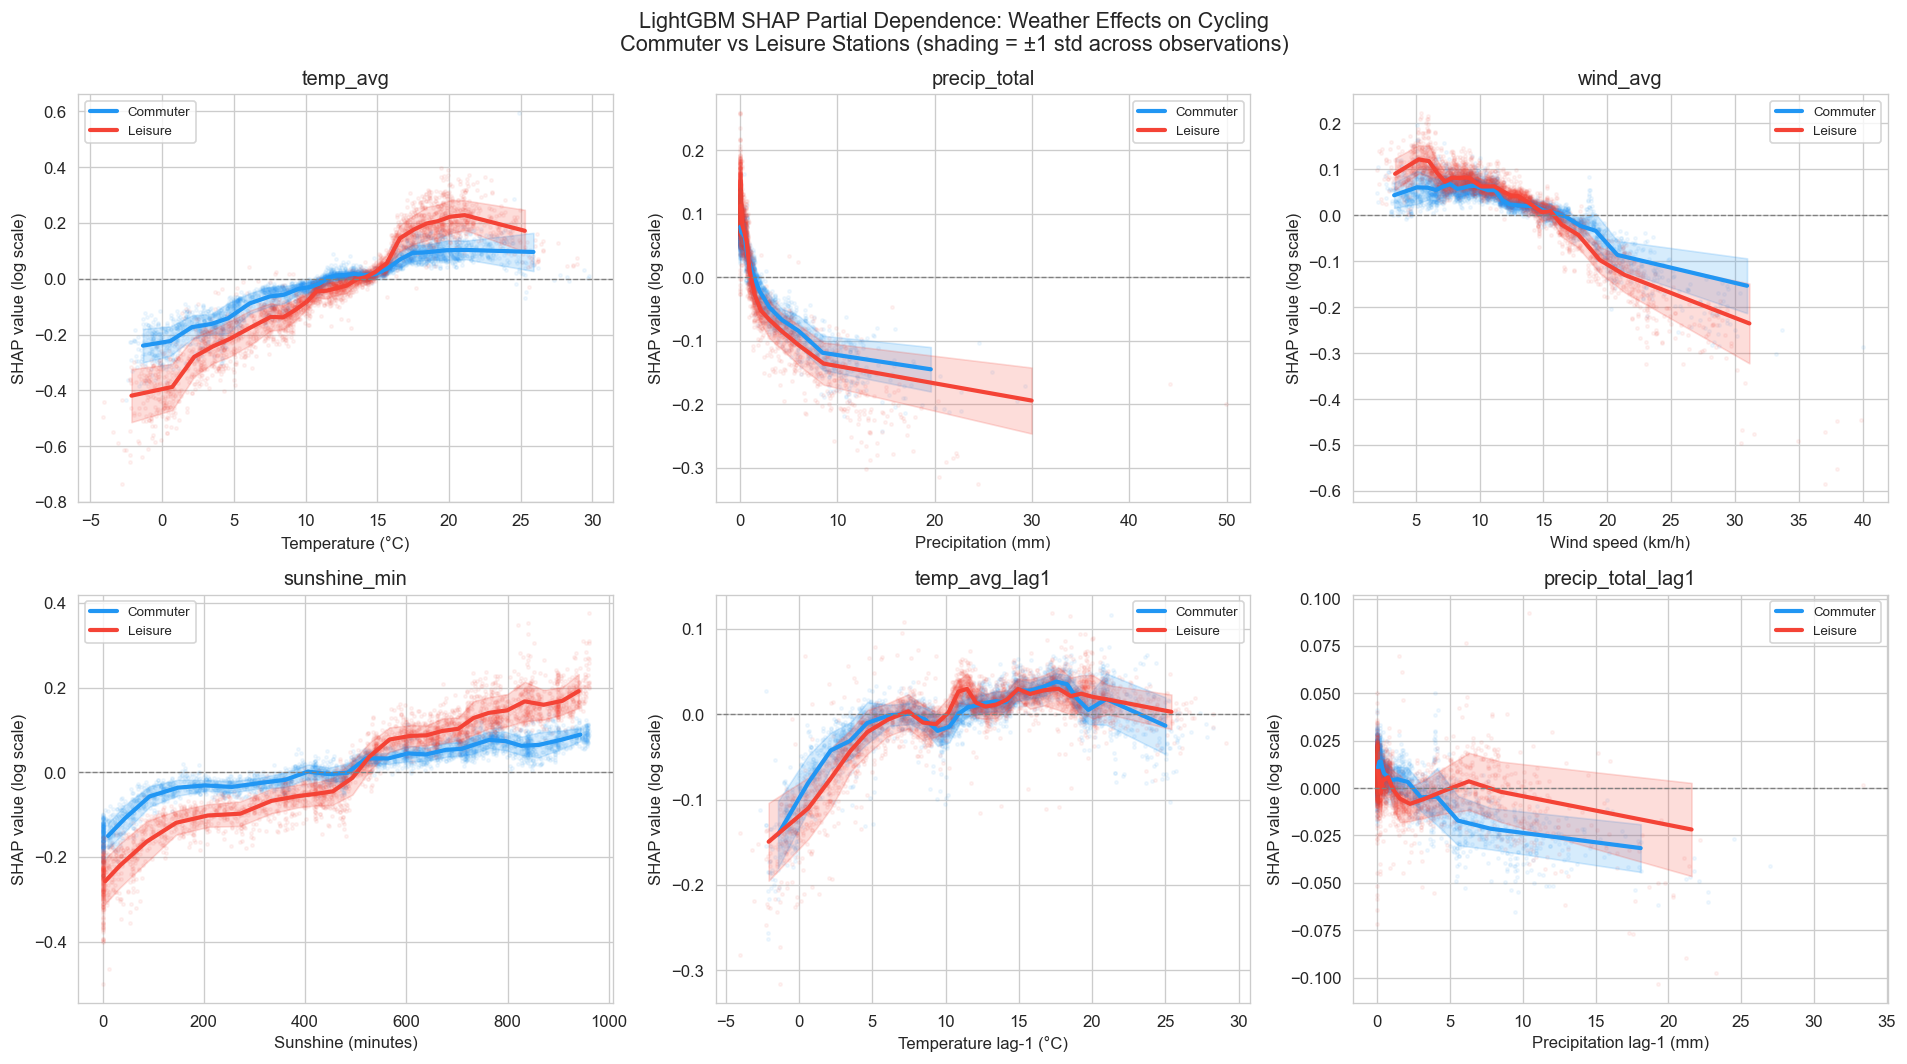

fig20b saved.


In [18]:
def shap_smooth(x_vals, shap_vals, n_bins=20):
    """Bin x_vals and return bin centres + mean ± 1 std of shap_vals per bin."""
    bins = np.percentile(x_vals, np.linspace(0, 100, n_bins + 1))
    bins = np.unique(bins)
    centres, means, stds = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (x_vals >= lo) & (x_vals < hi)
        if mask.sum() < 3:
            continue
        centres.append((lo + hi) / 2)
        means.append(shap_vals[mask].mean())
        stds.append(shap_vals[mask].std())
    return np.array(centres), np.array(means), np.array(stds)

# ── fig20b: 2×3 grid, same layout as fig20 ──────────────────────────────────
weather_terms = [
    (0, "temp_avg",          "Temperature (°C)"),
    (1, "precip_total",      "Precipitation (mm)"),
    (2, "wind_avg",          "Wind speed (km/h)"),
    (3, "sunshine_min",      "Sunshine (minutes)"),
    (5, "temp_avg_lag1",     "Temperature lag-1 (°C)"),
    (6, "precip_total_lag1", "Precipitation lag-1 (mm)"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (feat_idx, feat_name, xlabel) in zip(axes, weather_terms):
    x_c = X_test_c[idx_c_s, feat_idx]
    x_l = X_test_l[idx_l_s, feat_idx]
    s_c = shap_c[:, feat_idx]
    s_l = shap_l[:, feat_idx]

    # Raw scatter (low alpha)
    ax.scatter(x_c, s_c, alpha=0.06, s=4, color=COLORS["commuter"])
    ax.scatter(x_l, s_l, alpha=0.06, s=4, color=COLORS["leisure"])

    # Smooth line
    for x_v, s_v, color, label in [
        (x_c, s_c, COLORS["commuter"], "Commuter"),
        (x_l, s_l, COLORS["leisure"],  "Leisure"),
    ]:
        cx, cm, cs = shap_smooth(x_v, s_v, n_bins=25)
        ax.plot(cx, cm, color=color, linewidth=2.5, label=label)
        ax.fill_between(cx, cm - cs, cm + cs, alpha=0.18, color=color)

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("SHAP value (log scale)")
    ax.set_title(feat_name)
    ax.legend(fontsize=8)

fig.suptitle(
    "LightGBM SHAP Partial Dependence: Weather Effects on Cycling\n"
    "Commuter vs Leisure Stations (shading = ±1 std across observations)",
    fontsize=13,
)
fig.tight_layout()
fig.savefig(FIGS / "fig20b_lgb_shap_pdp.png", dpi=150)
plt.show()
print("fig20b saved.")


### 7b. SHAP Summary Plot (feature importance + direction)

C:\Users\word麻鸭\AppData\Local\Temp\ipykernel_23296\472818861.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\word麻鸭\AppData\Local\Temp\ipykernel_23296\472818861.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


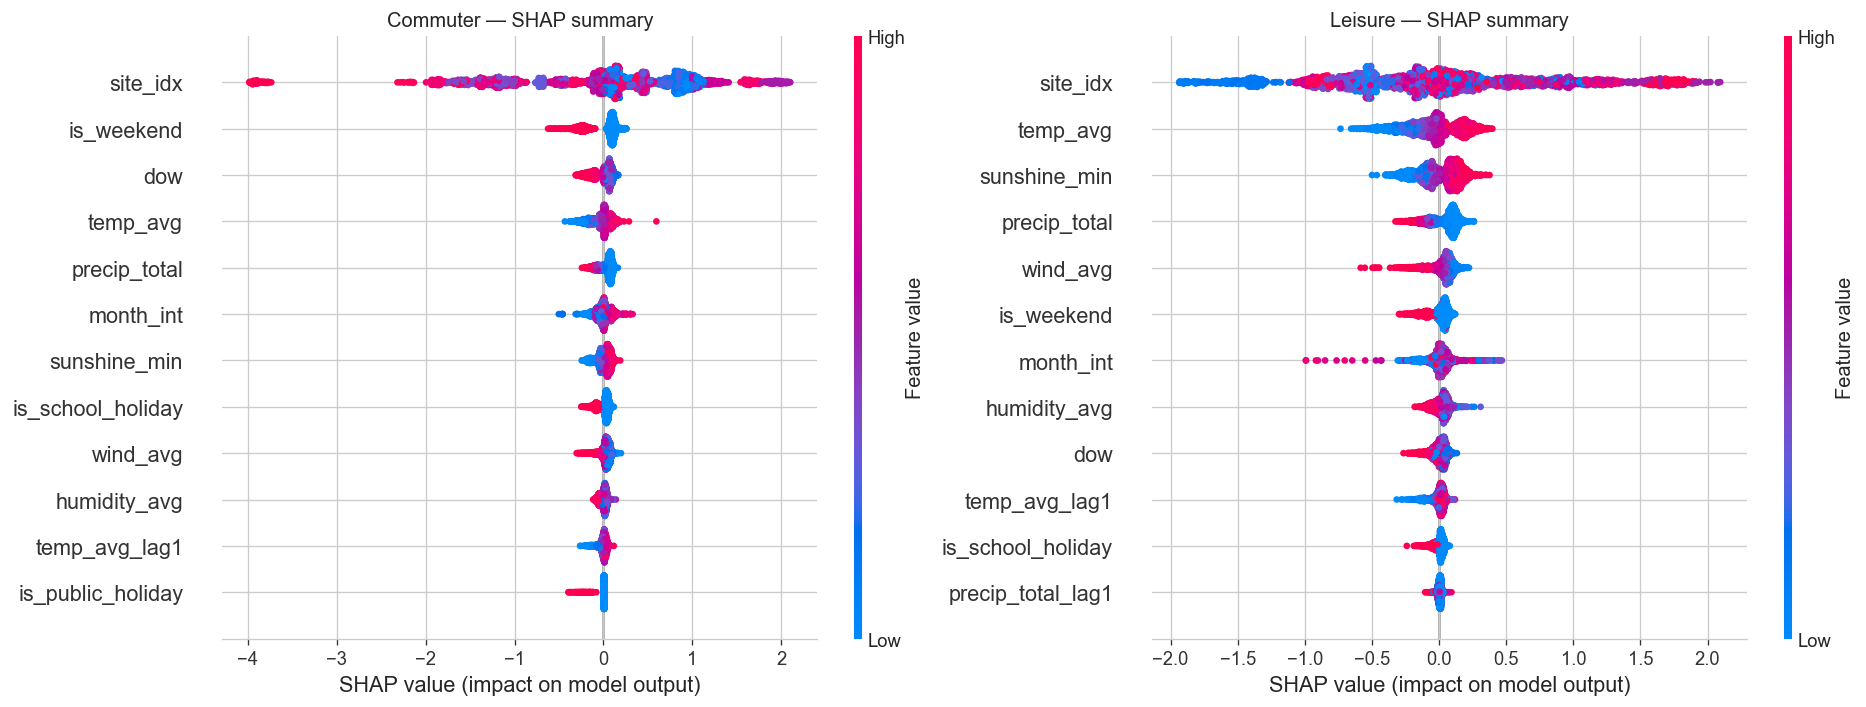

fig20c saved.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model, shap_vals, X_s, title) in zip(axes, [
    (lgb_commuter, shap_c, X_test_c[idx_c_s], "Commuter"),
    (lgb_leisure,  shap_l, X_test_l[idx_l_s], "Leisure"),
]):
    plt.sca(ax)
    shap.summary_plot(
        shap_vals,
        X_s,
        feature_names=ALL_FEATURES,
        max_display=12,
        show=False,
        plot_size=None,
    )
    ax.set_title(f"{title} — SHAP summary", fontsize=12)

plt.tight_layout()
fig.savefig(FIGS / "fig20c_lgb_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("fig20c saved.")


## 8. Weather-Normalized Cycling Index

Identical methodology to notebook 08: replace observed weather with a
reference-day profile and re-predict.  Saves to the **same parquet file**
so notebook 09 picks it up without changes.


Normalized cycling index saved — compatible with notebook 09.


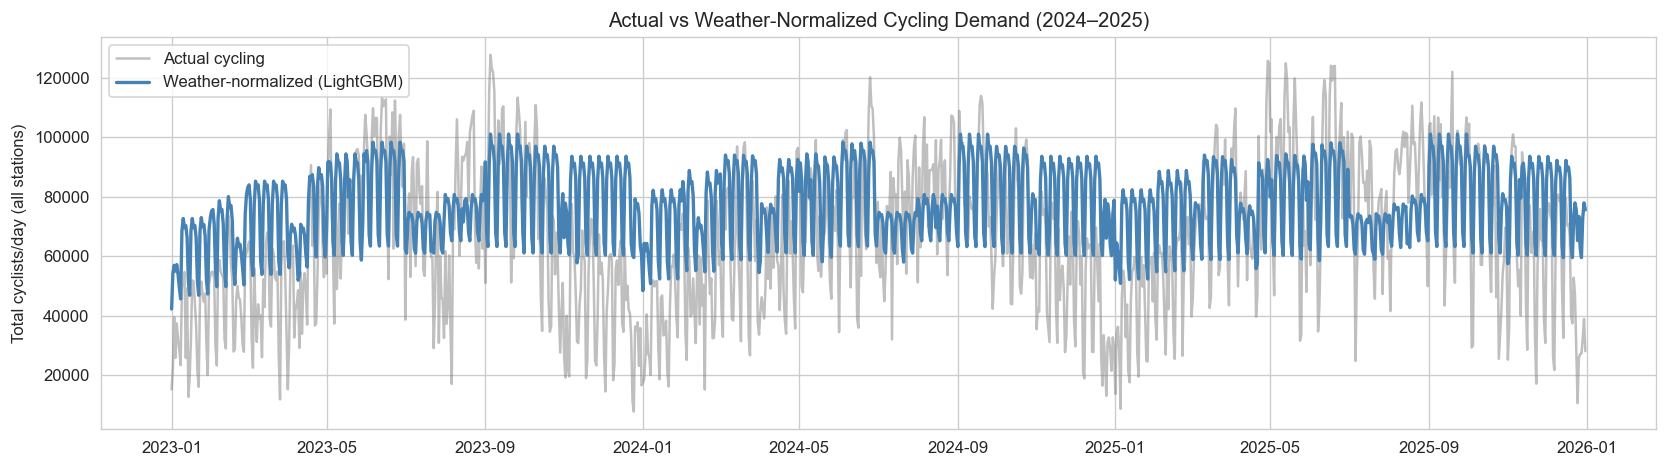

fig21b saved.


In [21]:
REF_WEATHER = {
    "temp_avg"          : 15.0,
    "precip_total"      : 0.0,
    "wind_avg"          : 10.0,
    "sunshine_min"      : 300.0,
    "humidity_avg"      : 70.0,
    "temp_avg_lag1"     : 15.0,
    "precip_total_lag1" : 0.0,
}

panel_norm = panel_good.copy()
panel_norm["date"]      = pd.to_datetime(panel_norm["date"])
panel_norm["site_idx"]  = le_site.transform(panel_norm["site ID"])
panel_norm["dow"]       = panel_norm["dayofweek"].astype(int)
panel_norm["month_int"] = panel_norm["month"].astype(int)
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_bad_weather"]:
    panel_norm[col] = panel_norm[col].astype(int)

X_norm = panel_norm[ALL_FEATURES].copy()
for feat, val in REF_WEATHER.items():
    X_norm[feat] = val

X_norm_clean     = X_norm.dropna()
panel_norm_clean = panel_norm.loc[X_norm_clean.index].copy()
panel_norm_clean["normalized_count"] = lgb_full.predict(
    X_norm_clean.values.astype(np.float64)
)
if "site_type" not in panel_norm_clean.columns:
    _s = pd.read_parquet(PROCESSED / "site_classification.parquet")[["site ID", "site_type"]]
    panel_norm_clean = panel_norm_clean.merge(_s, on="site ID", how="left")
    panel_norm_clean["site_type"] = panel_norm_clean["site_type"].fillna("unclassified")
panel_norm_clean[[
    "site ID", "naam", "date", "aantal",
    "normalized_count", "site_type", "day_type", "season"
]].to_parquet(PROCESSED / "normalized_cycling.parquet", index=False)
print("Normalized cycling index saved — compatible with notebook 09.")

# ── Plot (fig21b) ────────────────────────────────────────────────────────────
daily_actual = panel_norm_clean.groupby("date")["aantal"].sum()
daily_norm   = panel_norm_clean.groupby("date")["normalized_count"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_actual.index, daily_actual.values,
        alpha=0.5, color="gray", label="Actual cycling")
ax.plot(daily_norm.index, daily_norm.values,
        color="steelblue", linewidth=2, label="Weather-normalized (LightGBM)")
ax.set_title("Actual vs Weather-Normalized Cycling Demand (2024–2025)")
ax.set_ylabel("Total cyclists/day (all stations)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "fig21b_lgb_normalized_vs_actual.png", dpi=150)
plt.show()
print("fig21b saved.")


## 9. Weather Effect Magnitudes

Same comparisons as notebook 08 — percentage change in predicted demand
relative to a reference-weather baseline.


In [22]:
def weather_effect(model, ref_row, feature_idx, bad_val, ref_val):
    """% change in predicted count when feature moves from ref_val → bad_val."""
    X_bad          = ref_row.copy()
    X_ref          = ref_row.copy()
    X_bad[feature_idx] = bad_val
    X_ref[feature_idx] = ref_val
    pred_bad = model.predict(X_bad.reshape(1, -1))[0]
    pred_ref = model.predict(X_ref.reshape(1, -1))[0]
    return (pred_bad - pred_ref) / pred_ref * 100

# Reference rows: column means for each model's training set
ref_row   = X_train.mean(axis=0)
ref_row_c = X_train_c.mean(axis=0)
ref_row_l = X_train_l.mean(axis=0)

COMPARISONS = [
    ("Heavy rain (20mm vs 0mm)",    1, 20.0,   0.0),
    ("Light rain (2mm vs 0mm)",     1,  2.0,   0.0),
    ("Cold day (0°C vs 15°C)",      0,  0.0,  15.0),
    ("Cool day (8°C vs 15°C)",      0,  8.0,  15.0),
    ("Strong wind (40 vs 10 km/h)", 2, 40.0,  10.0),
    ("No sunshine (0 vs 300 min)",  3,  0.0, 300.0),
]

print("\n" + "=" * 65)
print("LGBM WEATHER EFFECT SIZES  (% change vs reference day)")
print("=" * 65)
print(f"{'Condition':<35} | {'Full':>7} | {'Commuter':>9} | {'Leisure':>8}")
print("-" * 65)
for label, feat_idx, bad_val, ref_val in COMPARISONS:
    ef = weather_effect(lgb_full,     ref_row,   feat_idx, bad_val, ref_val)
    ec = weather_effect(lgb_commuter, ref_row_c, feat_idx, bad_val, ref_val)
    el = weather_effect(lgb_leisure,  ref_row_l, feat_idx, bad_val, ref_val)
    print(f"{label:<35} | {ef:>6.1f}% | {ec:>8.1f}% | {el:>7.1f}%")
print("=" * 65)



LGBM WEATHER EFFECT SIZES  (% change vs reference day)
Condition                           |    Full |  Commuter |  Leisure
-----------------------------------------------------------------
Heavy rain (20mm vs 0mm)            |  -39.4% |    -35.6% |   -34.5%
Light rain (2mm vs 0mm)             |  -15.5% |    -11.8% |   -19.3%
Cold day (0°C vs 15°C)              |  -30.7% |    -25.2% |   -38.9%
Cool day (8°C vs 15°C)              |  -12.6% |    -12.2% |   -24.1%
Strong wind (40 vs 10 km/h)         |  -35.5% |    -31.6% |   -42.9%
No sunshine (0 vs 300 min)          |   -9.2% |    -14.2% |   -19.6%


### 9b. Interaction Deep-Dive: temperature × day type

Leisure cycling might respond differently to warm weekdays vs weekends.


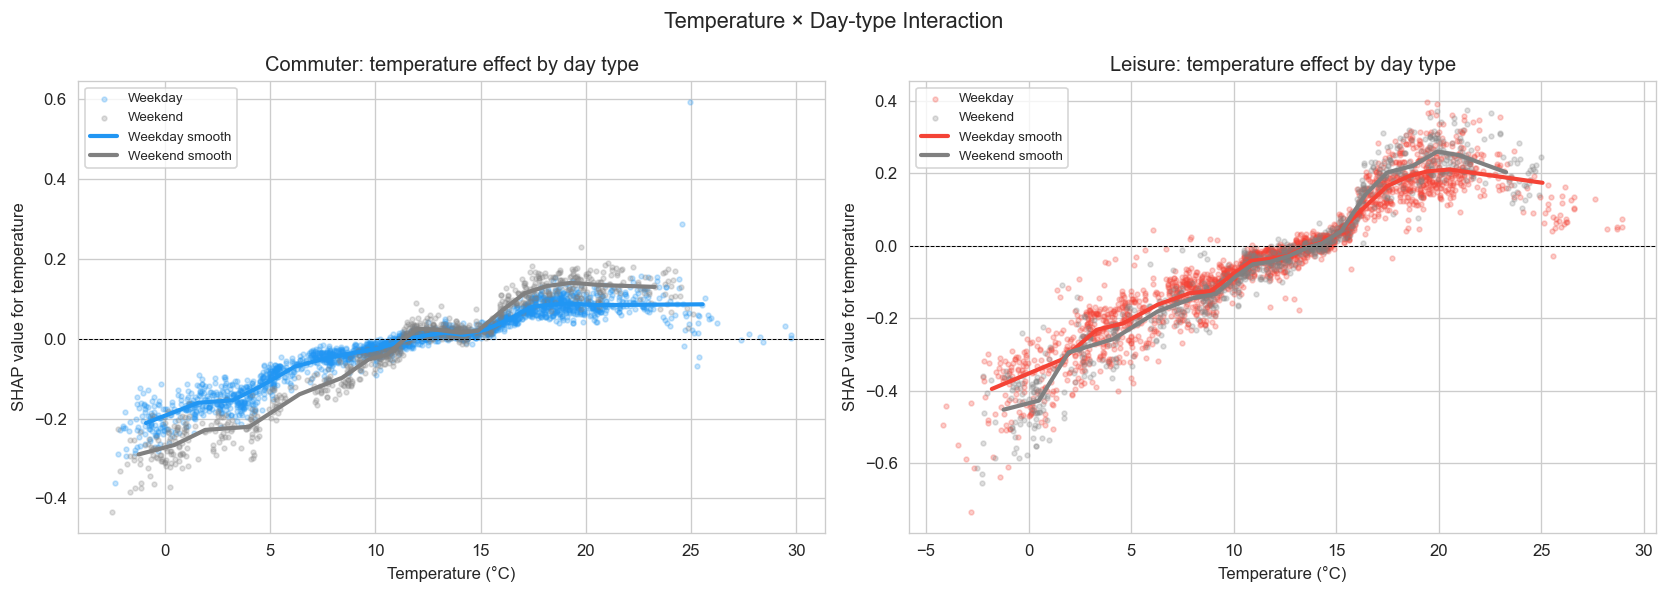

fig20d saved.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model, explainer, X_s, shap_v, title, color) in zip(axes, [
    (lgb_commuter, explainer_c, X_test_c[idx_c_s], shap_c,
     "Commuter", COLORS["commuter"]),
    (lgb_leisure,  explainer_l, X_test_l[idx_l_s], shap_l,
     "Leisure",  COLORS["leisure"]),
]):
    temp_idx    = ALL_FEATURES.index("temp_avg")
    weekend_idx = ALL_FEATURES.index("is_weekend")

    is_wknd   = X_s[:, weekend_idx].astype(bool)
    temp_vals  = X_s[:, temp_idx]
    shap_temp  = shap_v[:, temp_idx]

    ax.scatter(temp_vals[~is_wknd], shap_temp[~is_wknd],
               alpha=0.25, s=8, color=color,       label="Weekday")
    ax.scatter(temp_vals[ is_wknd], shap_temp[ is_wknd],
               alpha=0.25, s=8, color="gray",       label="Weekend")

    # LOWESS-style smoothing per group
    for mask, lcolor, lbl in [
        (~is_wknd, color, "Weekday smooth"),
        ( is_wknd, "gray", "Weekend smooth"),
    ]:
        cx, cm, _ = shap_smooth(temp_vals[mask], shap_temp[mask], n_bins=20)
        ax.plot(cx, cm, color=lcolor, linewidth=2.5, label=lbl)

    ax.axhline(0, color="black", linestyle="--", linewidth=0.6)
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("SHAP value for temperature")
    ax.set_title(f"{title}: temperature effect by day type")
    ax.legend(fontsize=8)

fig.suptitle("Temperature × Day-type Interaction", fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "fig20d_temp_daytype_interaction.png", dpi=150)
plt.show()
print("fig20d saved.")


## 10. Save Models

Saves to the **same pickle path** as notebook 08 (`gam_models.pkl`).
The dict keys `gam_full`, `gam_commuter`, `gam_leisure` are kept for
compatibility with notebook 09's `models["gam_full"]` references.


In [25]:
models = {
    # Keys match notebook 08 / 09 expectations
    "gam_full"     : lgb_full,
    "gam_commuter" : lgb_commuter,
    "gam_leisure"  : lgb_leisure,
    "le_site"      : le_site,
    "le_commuter"  : le_c,
    "le_leisure"   : le_l,
    # Extra metadata
    "model_type"   : "lightgbm_poisson",
    "all_features" : ALL_FEATURES,
    "ref_weather"  : REF_WEATHER,
}
with open(PROCESSED / "gam_models.pkl", "wb") as fh:
    pickle.dump(models, fh)
print(f"Models saved to {PROCESSED / 'gam_models.pkl'}")

# Also save native LightGBM format for inspection
#lgb_full.save_model(str(PROCESSED / "lgb_full.txt"))
#lgb_commuter.save_model(str(PROCESSED / "lgb_commuter.txt"))
#lgb_leisure.save_model(str(PROCESSED / "lgb_leisure.txt"))
print("Native LightGBM models saved (.txt)")


Models saved to C:\Users\word麻鸭\mda-cycling-weather-group6\data\processed\gam_models.pkl
Native LightGBM models saved (.txt)


## 11. Final Summary

In [26]:
heavy_rain_full = weather_effect(lgb_full, ref_row, 1, 20.0, 0.0)
cold_day_full   = weather_effect(lgb_full, ref_row, 0,  0.0, 15.0)
strong_wind_full= weather_effect(lgb_full, ref_row, 2, 40.0, 10.0)

print("=" * 52)
print("LIGHTGBM MODELLING SUMMARY")
print("=" * 52)
print(f"Training period : 2024 ({len(y_train):,} observations)")
print(f"Test period     : 2025 ({len(y_test):,} observations)")
print()
print("Model performance (test set):")
print(f"  Full LightGBM     : MAE={mae_full:.1f}, R²={r2_full:.3f}")
print(f"  Commuter LightGBM : MAE={mae_c:.1f}, R²={r2_c:.3f}")
print(f"  Leisure LightGBM  : MAE={mae_l:.1f}, R²={r2_l:.3f}")
print()
print("Key weather effects (full model):")
print(f"  Heavy rain (20mm) : {heavy_rain_full:+.1f}%")
print(f"  Cold day (0°C)    : {cold_day_full:+.1f}%")
print(f"  Strong wind       : {strong_wind_full:+.1f}%")
print()
print("Outputs saved:")
print(f"  {PROCESSED / 'normalized_cycling.parquet'}")
print(f"  {PROCESSED / 'gam_models.pkl'}")
print(f"  {PROCESSED / 'lgb_full.txt'} / lgb_commuter.txt / lgb_leisure.txt")
print(f"  {FIGS / 'fig20b_lgb_shap_pdp.png'}")
print(f"  {FIGS / 'fig20c_lgb_shap_summary.png'}")
print(f"  {FIGS / 'fig20d_temp_daytype_interaction.png'}")
print(f"  {FIGS / 'fig21b_lgb_normalized_vs_actual.png'}")
print("=" * 52)
print()
print("Notebooks 09 & 10 are fully compatible — no changes needed.")


LIGHTGBM MODELLING SUMMARY
Training period : 2024 (48,351 observations)
Test period     : 2025 (48,151 observations)

Model performance (test set):
  Full LightGBM     : MAE=118.1, R²=0.852
  Commuter LightGBM : MAE=116.9, R²=0.782
  Leisure LightGBM  : MAE=127.3, R²=0.785

Key weather effects (full model):
  Heavy rain (20mm) : -39.4%
  Cold day (0°C)    : -30.7%
  Strong wind       : -35.5%

Outputs saved:
  C:\Users\word麻鸭\mda-cycling-weather-group6\data\processed\normalized_cycling.parquet
  C:\Users\word麻鸭\mda-cycling-weather-group6\data\processed\gam_models.pkl
  C:\Users\word麻鸭\mda-cycling-weather-group6\data\processed\lgb_full.txt / lgb_commuter.txt / lgb_leisure.txt
  C:\Users\word麻鸭\mda-cycling-weather-group6\outputs\figures\fig20b_lgb_shap_pdp.png
  C:\Users\word麻鸭\mda-cycling-weather-group6\outputs\figures\fig20c_lgb_shap_summary.png
  C:\Users\word麻鸭\mda-cycling-weather-group6\outputs\figures\fig20d_temp_daytype_interaction.png
  C:\Users\word麻鸭\mda-cycling-weather-group6\